In [37]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

from src.models.utils import *
import pandas as pd

In [38]:
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *


In [39]:
l_min = 4
max_diff = 3
c_thresh = 0.9

csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(inplace=True)

feature_adder = Feature_adder(df)
feature_adder.select_gas_plants()
feature_adder.filter1()


2025-10-21 10:23:59 - src.models.filter_data.feature_adder - INFO - 32.88% of rows have been chosen by filter1


In [40]:
feature_adder.filter2(l_min=l_min, max_diff=max_diff, initial_label=1)

2025-10-21 10:24:09 - src.models.filter_data.feature_adder - INFO - 55.46% of rows have been chosen by filter2


In [41]:
feature_adder.filter3("temp_sens", c_thresh=c_thresh, initial_label=2)

2025-10-21 10:24:28 - src.models.filter_data.feature_adder - INFO - 53.86% of rows have been chosen by filter3


In [42]:
feature_adder.filter4(initial_label=3)

جنوب اصفهان - چهلستون G12
1 2021-06-01 16:00:00 2021-06-01 20:00:00
جنوب اصفهان - چهلستون G13
1 2021-06-01 16:00:00 2021-06-01 20:00:00
جنوب اصفهان - چهلستون G14
0 2021-06-01 16:00:00 2021-06-01 13:00:00
جنوب اصفهان - چهلستون G15
1 2021-06-01 16:00:00 2021-06-01 20:00:00
جنوب اصفهان - چهلستون G16
1 2021-06-01 16:00:00 2021-06-01 20:00:00
سبلان G12
6 2021-05-01 22:00:00 2021-11-01 21:00:00
سبلان G13
4 2021-05-01 21:00:00 2021-09-01 17:00:00
سبلان G14
6 2021-05-01 21:00:00 2021-10-01 21:00:00
سبلان G15
6 2021-05-01 21:00:00 2021-10-01 21:00:00
سبلان G16
6 2021-05-01 21:00:00 2021-10-01 21:00:00
سیکل ترکیبی ارومیه G12
11 2021-05-01 09:00:00 2022-03-01 21:00:00
سیکل ترکیبی ارومیه G13
11 2021-05-01 21:00:00 2022-03-01 21:00:00
سیکل ترکیبی ارومیه G14
11 2021-05-01 21:00:00 2022-03-01 21:00:00
سیکل ترکیبی ارومیه G15
11 2021-05-01 11:00:00 2022-03-01 21:00:00
سیکل ترکیبی ارومیه G16
11 2021-05-01 11:00:00 2022-03-01 21:00:00
سیکل ترکیبی یزد G14
10 2021-10-01 18:00:00 2022-08-01 00:00:00
شهدای پ

2025-10-21 10:24:48 - src.models.filter_data.feature_adder - INFO - 78.85% of rows have been chosen by filter4


In [43]:
import plotly.express as px
def show(df_m1,save=False,param=None,ass=""):

    '''
    fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                    title='Generation over Time by Batch Interval',
                    labels={'generation': 'Generation', 'datetime': 'Time'},
                    hover_data=['datetime', 'generation', 'temperature','interval_id'])
    
    if save : fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}.html")
    else : fig.show()
    '''
    
    fig = px.scatter(df_m1, x="temperature", y='generation', color='is_good_peak',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation'},
                hover_data=['generation', 'temperature'])
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_s.html")
    else: fig.show()

In [44]:
name_plot = "پرند"
code_plot = "G12"
df_plot = feature_adder.df.copy()
ds_n_c_plot = Data_selector(Data_selector(df_plot).select_peaks(goodness=4))
df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
show(df_n_c_plot,save=True,param={"name":name_plot,"code":code_plot})

In [45]:
df_c = feature_adder.df.copy()

In [46]:
def select_envelope_neighbors_indices(X, y, one_unit_df, alpha, beta):
    model = LinearRegression()
    model.fit(X, y)

    sens_temps = one_unit_df['temp_sens'].values
    gens = one_unit_df['generation'].values
    X_all = sens_temps.reshape(-1, 1)
    y_pred_all = model.predict(X_all)

    is_in_area = (y_pred_all + alpha >= gens) & (gens >= y_pred_all - beta)
    return X_all, y_pred_all, is_in_area, one_unit_df[is_in_area].index

In [47]:
features = ["name", "code", "generation", "temp_sens", "is_good_peak"]
df_modified = df_c[features].copy(deep=True)
df_modified = df_modified[df_modified["is_good_peak"] >= 4]
ds = Data_selector(df_modified)

all_indices = []
power_plants = df_modified[['name', 'code']].drop_duplicates()

name, code = name_plot,code_plot
one_unit_df = ds.filter_name_code(name, code)

sens_temps = one_unit_df['temp_sens'].values
gens = one_unit_df['generation'].values

X, y = find_points_on_envelope(gens, sens_temps)

X_all, y_pred_all, is_in_area, near_envelope_indices = select_envelope_neighbors_indices(X, y, one_unit_df, alpha=2, beta=5)
all_indices.extend(near_envelope_indices)

df_c.loc[all_indices, "is_good_peak"] = 5

In [48]:
ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=4))
df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
show(df_n_c_plot,save=True,param={"name":name_plot,"code":code_plot})

In [60]:
(one_unit_df[is_in_area].index == df_c[df_c['is_good_peak'].values == 5].index).all()


np.True_

Index([33109, 33111, 33113, 33195, 36521, 36523, 36604, 36606, 36607, 36610,
       ...
       61567, 61568, 61571, 61651, 61653, 61655, 61658, 61659, 61662, 61664],
      dtype='int64', length=727)

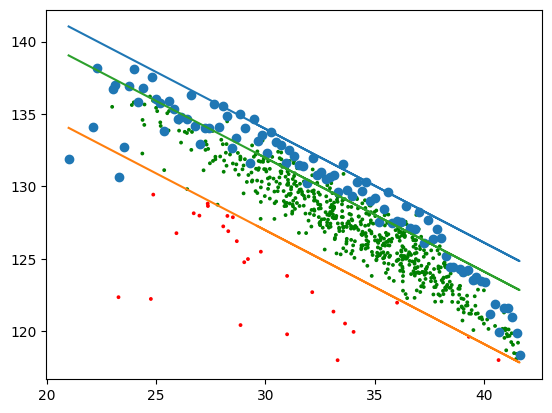

In [50]:
colors = ['green' if val else 'red' for val in is_in_area]
plt.scatter(X_all,gens,s=3,color=colors)

plt.plot(X_all,y_pred_all + 2)
plt.plot(X_all,y_pred_all - 5)
plt.plot(X_all,y_pred_all)
plt.scatter(X,y)
